**[Cell 1] 라이브러리 로드**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

**[Cell 2] Metadata & Split 로드**

In [4]:
# load metadata
df = pd.read_csv("/data/ephemeral/home/wooqi00_test/Validation_split/outputs/metadata_with_subject.csv")

# utility to load split
def load_split(path):
    with open(path) as f:
        return set(line.strip() for line in f)

splits = {
    "S1": load_split("/data/ephemeral/home/wooqi00_test/splits_outputs/s1/val.txt"),
    "S2": load_split("/data/ephemeral/home/wooqi00_test/splits_outputs/s2/val.txt"),
    "S3": load_split("/data/ephemeral/home/wooqi00_test/splits_outputs/s3/val.txt"),
}

# sanity check
for name, ids in splits.items():
    print(f"{name}: {len(ids)} validation images")

S1: 159 validation images
S2: 159 validation images
S3: 159 validation images


**[Cell 2] Basic sanity check**

In [5]:
for name, ids in splits.items():
    print(name, len(ids))

S1 159
S2 159
S3 159


**[Cell 3] Difficulty Score 재계산 (안전용)**

In [6]:
def rank_normalize(x):
    return x.rank(method="average") / len(x)

df["difficulty_score"] = (
    rank_normalize(df["overlap_pixels"]) +
    rank_normalize(df["boundary_adj_pixels"]) +
    rank_normalize(df["small_mask_outlier_count"])
)

**[Cell 4] Difficulty 분포 시각화 함수 (핵심)**

In [7]:
def plot_difficulty_distribution(split_name):
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df,
        x="difficulty_score",
        hue=df["image_id"].isin(splits[split_name]),
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title(f"Difficulty Distribution ({split_name})")
    plt.xlabel("Difficulty Score")
    plt.legend(title="Split", labels=["Train", "Val"])
    plt.tight_layout()
    plt.show()

**[Cell 5] S1 / S2 / S3 Difficulty 분포 비교**

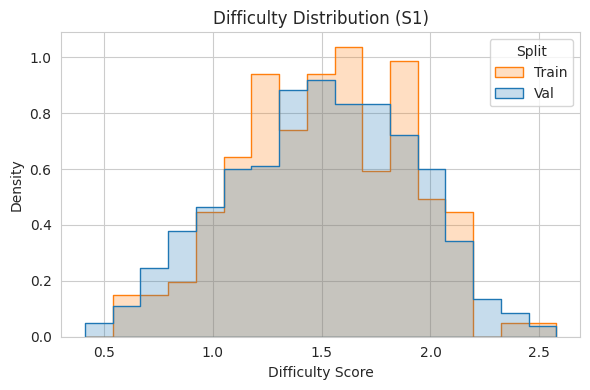

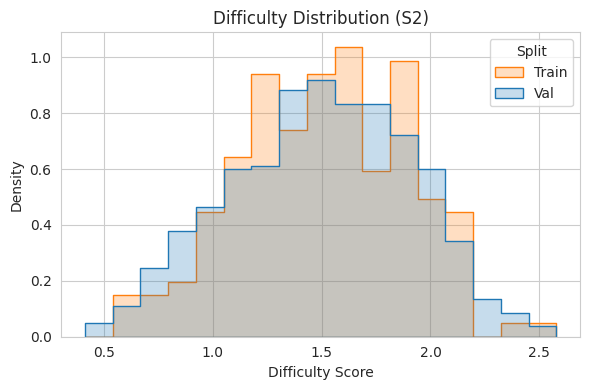

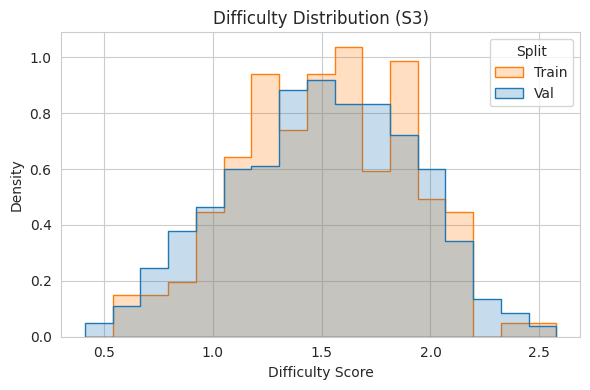

In [8]:
for split_name in ["S1", "S2", "S3"]:
    plot_difficulty_distribution(split_name)

**[Cell 6] Boundary-heavy 비율 검증 (S2 핵심)**

In [9]:
# boundary-heavy 기준 (전체 기준 상위 25%)
boundary_thr = df["boundary_adj_pixels"].quantile(0.75)
df["is_boundary_heavy"] = df["boundary_adj_pixels"] >= boundary_thr

overall_ratio = df["is_boundary_heavy"].mean()
print(f"Overall boundary-heavy ratio: {overall_ratio:.3f}")

for name in ["S1", "S2", "S3"]:
    val_ratio = df[df["image_id"].isin(splits[name])]["is_boundary_heavy"].mean()
    print(f"{name} val boundary-heavy ratio: {val_ratio:.3f}")

Overall boundary-heavy ratio: 0.251
S1 val boundary-heavy ratio: 0.258
S2 val boundary-heavy ratio: 0.258
S3 val boundary-heavy ratio: 0.258


**[Cell 7] Small-structure Stress 검증 (S3 핵심)**

In [ ]:
# small-structure stress 정의 (split_s3와 동일)
low_ratio_thr = df["small_class_pixel_ratio"].quantile(0.20)

df["is_small_stress"] = (
    (df["small_class_pixel_ratio"] <= low_ratio_thr) |
    (df["small_mask_outlier_count"] >= 2)
)

overall_ratio = df["is_small_stress"].mean()
print(f"Overall small-stress ratio: {overall_ratio:.3f}")

for name in ["S2", "S3"]:
    val_ratio = df[df["image_id"].isin(splits[name])]["is_small_stress"].mean()
    print(f"{name} val small-stress ratio: {val_ratio:.3f}")

Overall small-stress ratio: 0.339
S2 val small-stress ratio: 0.333
S3 val small-stress ratio: 0.333
